# Model Training and Analysis

This notebook prepares deep-learning experiments for image watermarking, runs training on a small subset and the full dataset, and compares their results.

In [1]:
import os
import sys
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.train import TrainConfig, run_training
from src.utils import set_seed, SEED

In [2]:
DATA_DIR = Path("../data")
SPLITS_FILE = DATA_DIR / "splits.json"

## Helper Functions

We will first define functions for preparing a smaller split and for loading, summarizing and visualizing the results.

In [3]:
def make_subset_splits_file(source_splits_file, output_splits_file, n_train=16, n_val=4, n_test=4):
    """Create a small split with the first `n` images of each split from an existing one."""

    with open(source_splits_file, "r") as f:
        splits = json.load(f)

    subset = {
        "train": splits["train"][:n_train],
        "val": splits["val"][:n_val],
        "test": splits["test"][:n_test],
    }

    output_splits_file = Path(output_splits_file)
    output_splits_file.parent.mkdir(parents=True, exist_ok=True)
    with output_splits_file.open("w") as f:
        json.dump(subset, f, indent=2)

    return output_splits_file

In [4]:
def load_training_log(log_path):
    """Load a log file written by training function into a pandas DataFrame."""

    log_path = Path(log_path)
    if not log_path.exists():
        raise FileNotFoundError(f"No log file found at {log_path}")

    return pd.read_csv(log_path)


def summarize_training_log(df, name=""):
    """Print the best/last epoch stats for a training log."""

    best_row = df.loc[df["val_loss"].idxmin()]
    last_row = df.iloc[-1]

    title = f"Summary for {name}" if name else "Summary"
    print(title)
    print("-" * len(title))
    print(f"Epochs run: {int(last_row['epoch'])}")
    print(f"Best epoch: {int(best_row['epoch'])} (val_loss={best_row['val_loss']:.4f})")
    print(f"  val_ber={best_row['val_ber']:.4f}, val_exact_accuracy={best_row['val_exact_accuracy']:.4f}, val_psnr={best_row['val_psnr']:.2f}")
    print("Last epoch stats:")
    print(f"  train_loss={last_row['train_loss']:.4f}, val_loss={last_row['val_loss']:.4f}")
    print(f"  val_ber={last_row['val_ber']:.4f}, val_exact_accuracy={last_row['val_exact_accuracy']:.4f}, val_psnr={last_row['val_psnr']:.2f}")

    return best_row, last_row


def plot_training_log(df, name="", metrics=("loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr")):
    """Plot train vs. validation curves for each metric found in a training log."""

    metrics = [m for m in metrics if f"train_{m}" in df.columns or f"val_{m}" in df.columns]
    n_cols = 3
    n_rows = -(-len(metrics) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for i, metric in enumerate(metrics):
        ax = axes[i // n_cols][i % n_cols]
        if f"train_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"train_{metric}"], label="train")
        if f"val_{metric}" in df.columns:
            ax.plot(df["epoch"], df[f"val_{metric}"], label="val")
        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()

    for j in range(len(metrics), n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    fig.suptitle(name)
    fig.tight_layout()
    plt.show()


def analyze_run(log_path, name=""):
    """Load, summarize and plot a training run log file."""

    df = load_training_log(log_path)
    summarize_training_log(df, name=name)
    plot_training_log(df, name=name)
    return df

## Small-Subset Training

We first run a short experiment on the small subset as a quick sanity check before considering the full training run.

In [6]:
SMALL_SPLIT_FILE = make_subset_splits_file(SPLITS_FILE, DATA_DIR / "splits_small.json", n_train=16, n_val=4, n_test=4)
SMALL_SPLIT_FILE

WindowsPath('../data/splits_small.json')

Summary for Small overfit test
------------------------------
Epochs run: 200
Best epoch: 85 (val_loss=0.3243)
  val_ber=0.1172, val_exact_accuracy=0.2500, val_psnr=5.33
Last epoch stats:
  train_loss=0.3193, val_loss=0.4667
  val_ber=0.1719, val_exact_accuracy=0.2500, val_psnr=5.31


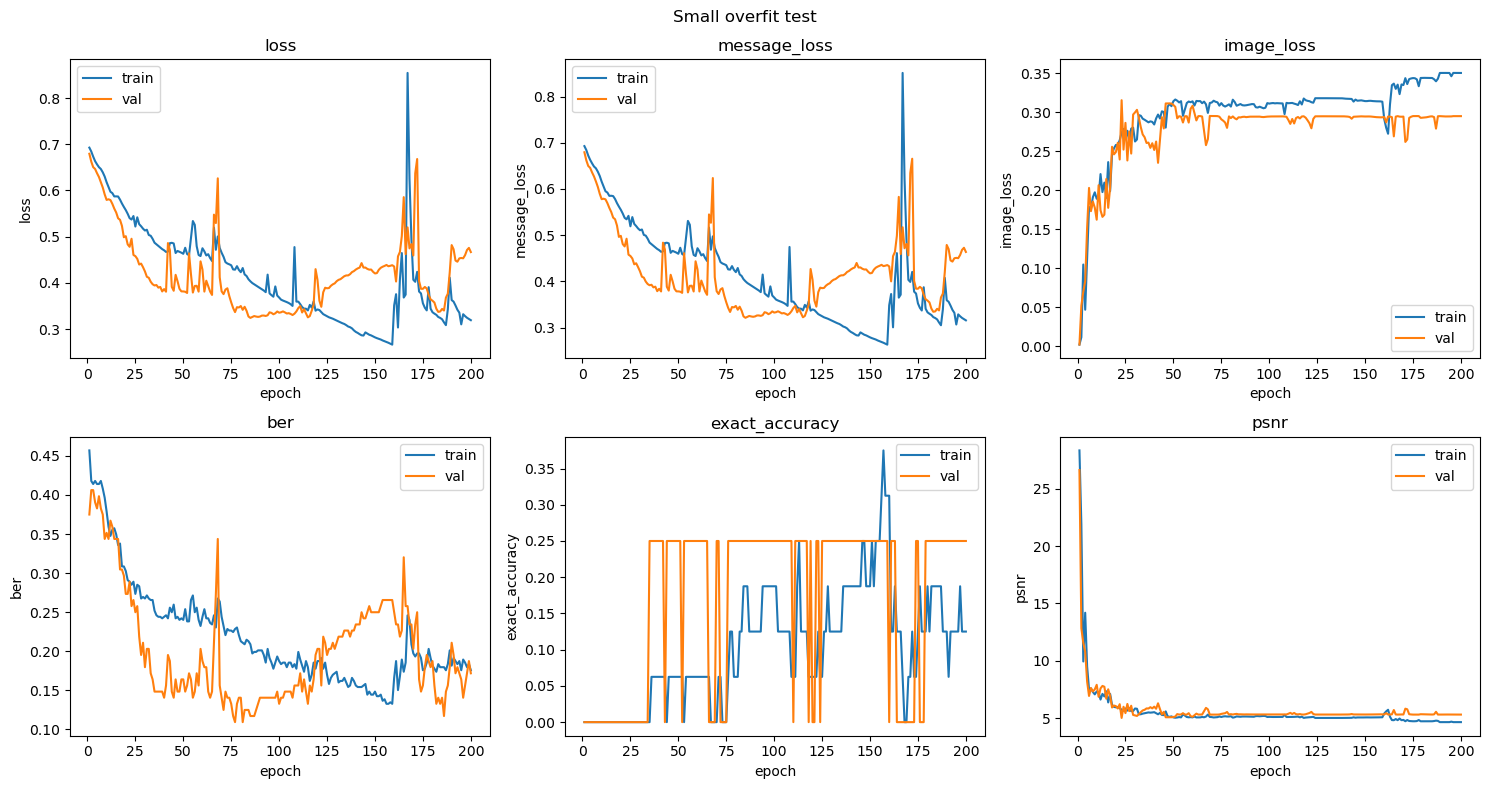

In [7]:
small_config = TrainConfig(epochs=200, batch_size=4, message_length=32, learning_rate=1e-3, image_loss_weight=0.01, device="cuda",
                           checkpoint_dir="../results/small_overfit/checkpoints", log_path="../results/small_overfit/experiments.csv")

with open(SMALL_SPLIT_FILE, "r") as f:
    n_train_images = len(json.load(f)["train"])

fixed_train_messages = torch.randint(0, 2, (n_train_images, small_config.message_length), generator=torch.Generator().manual_seed(SEED), dtype=torch.float32)

small_encoder, small_decoder, small_history = run_training(data_dir=DATA_DIR, splits_file=SMALL_SPLIT_FILE, config=small_config, num_workers=0,
                                                           fixed_train_messages=fixed_train_messages, shuffle_train=False)

small_df = analyze_run(small_config.log_path, name="Small overfit test")

### Small Overfit Test Results

This test uses fixed 32-bit messages for the training images. After 200 epochs, the final training BER is 0.176 and training exact message accuracy is 0.125. On the validation split, the BER is 0.172 and exact message accuracy is 0.25. The message loss is 0.316 for training and 0.464 for validation, showing that the model learns part of the message signal.

Image quality is poor in this configuration. The final training PSNR is 4.65 dB and validation PSNR is 5.31 dB, with image losses of 0.350 and 0.295. The test therefore shows partial message recovery, but the embedding produces substantial image distortion.

## Full-Dataset Training

We then train the same model on the full dataset to examine whether the larger sample provides more stable learning and better watermark recovery.

Summary for Full dataset
------------------------
Epochs run: 20
Best epoch: 4 (val_loss=0.6930)
  val_ber=0.4923, val_exact_accuracy=0.0000, val_psnr=64.82
Last epoch stats:
  train_loss=0.6932, val_loss=0.6932
  val_ber=0.5005, val_exact_accuracy=0.0000, val_psnr=83.56


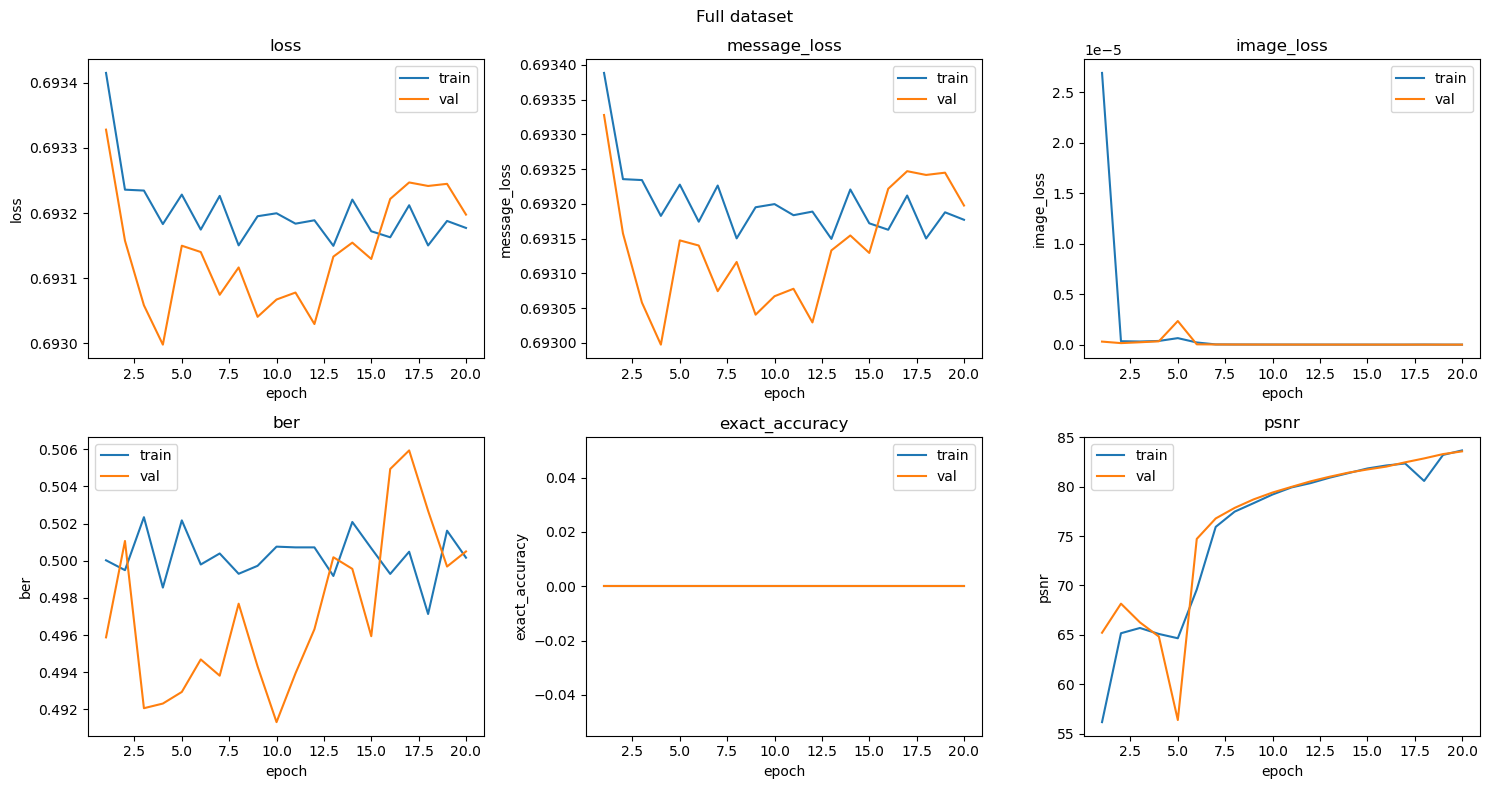

In [12]:
full_config = TrainConfig(epochs=20, batch_size=32, message_length=32, learning_rate=1e-3, device="cuda",
                          checkpoint_dir="../results/full/checkpoints", log_path="../results/full/experiments.csv")

full_encoder, full_decoder, full_history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=full_config, num_workers=4)

full_df = analyze_run(full_config.log_path, name="Full dataset")

### Small and Full Dataset Comparison

The current small overfit test achieves partial message recovery: training and validation BER are 0.176 and 0.172, while exact message accuracy is 0.125 and 0.25. Its validation PSNR is 5.31 dB, so this message recovery comes with substantial image distortion.

The current full-dataset run preserves the image much better, reaching a validation PSNR of 83.56 dB. However, its validation BER is 0.501 and exact message accuracy is 0, which indicates that the message is not being recovered reliably.

Together, these current results show a clear trade-off. The small overfit configuration learns some message information but damages the image, whereas the full-dataset configuration preserves the image but does not learn the watermark. The next experiment should search for a better balance by increasing `image_loss_weight` gradually from the small-test setting while monitoring BER, exact accuracy, and PSNR.

Summary for full_balanced
-------------------------
Epochs run: 20
Best epoch: 20 (val_loss=0.6276)
  val_ber=0.4243, val_exact_accuracy=0.0000, val_psnr=14.02
Last epoch stats:
  train_loss=0.6304, val_loss=0.6276
  val_ber=0.4243, val_exact_accuracy=0.0000, val_psnr=14.02


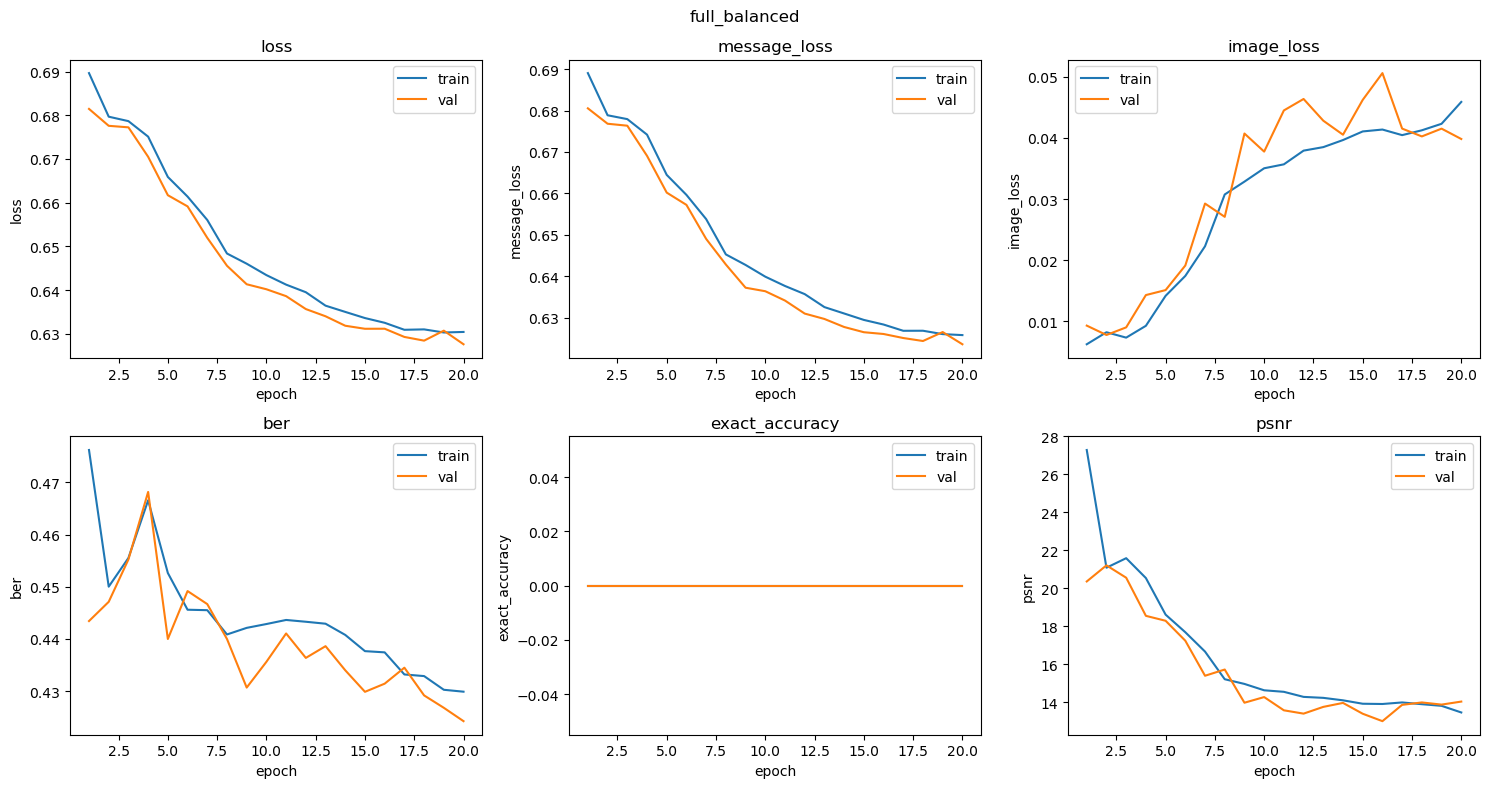

Summary for full_balanced_low_lr
--------------------------------
Epochs run: 20
Best epoch: 20 (val_loss=0.6084)
  val_ber=0.3970, val_exact_accuracy=0.0000, val_psnr=13.28
Last epoch stats:
  train_loss=0.6107, val_loss=0.6084
  val_ber=0.3970, val_exact_accuracy=0.0000, val_psnr=13.28


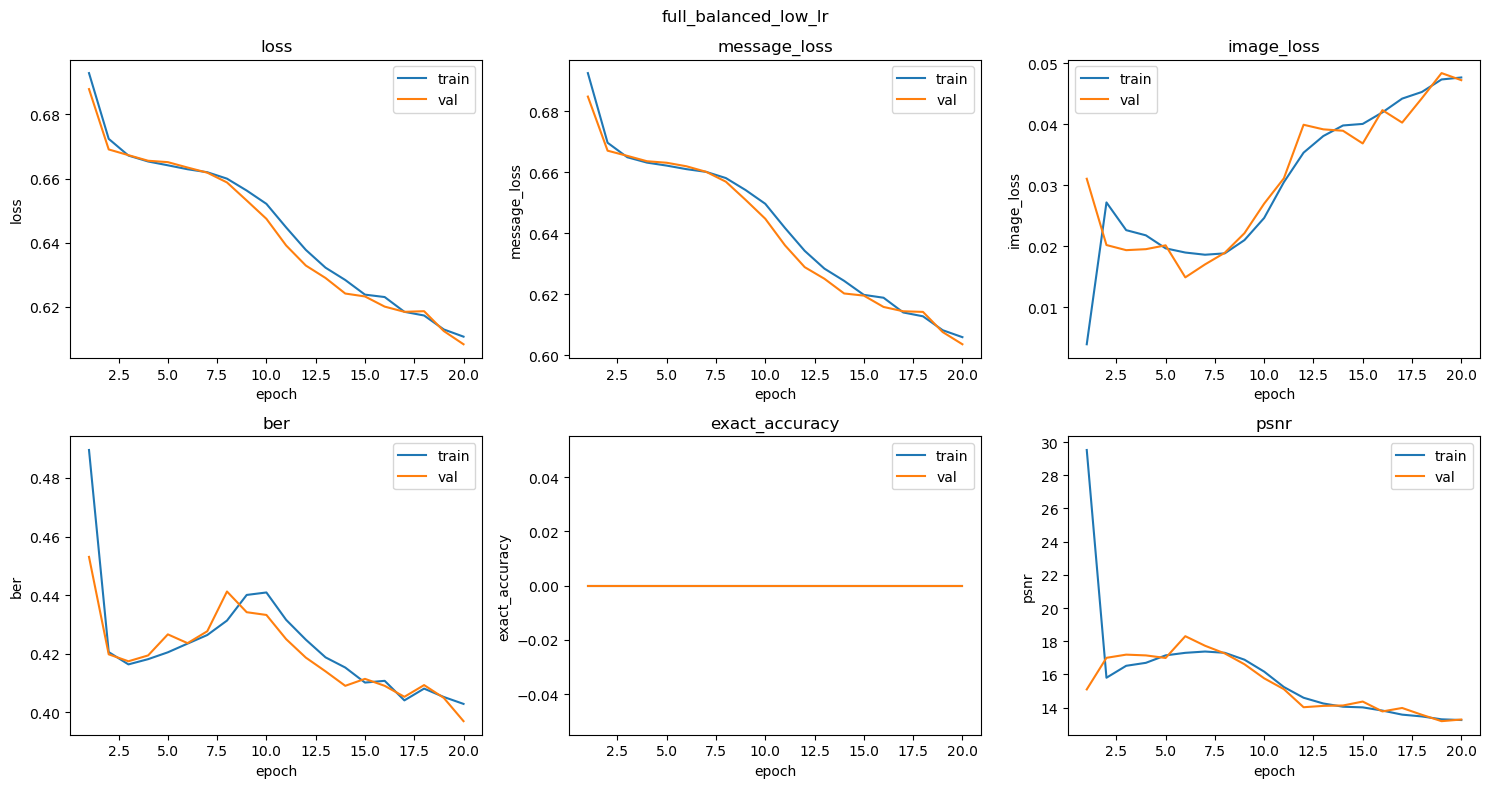

Summary for full_message_focused
--------------------------------
Epochs run: 20
Best epoch: 20 (val_loss=0.5787)
  val_ber=0.3738, val_exact_accuracy=0.0000, val_psnr=9.19
Last epoch stats:
  train_loss=0.5856, val_loss=0.5787
  val_ber=0.3738, val_exact_accuracy=0.0000, val_psnr=9.19


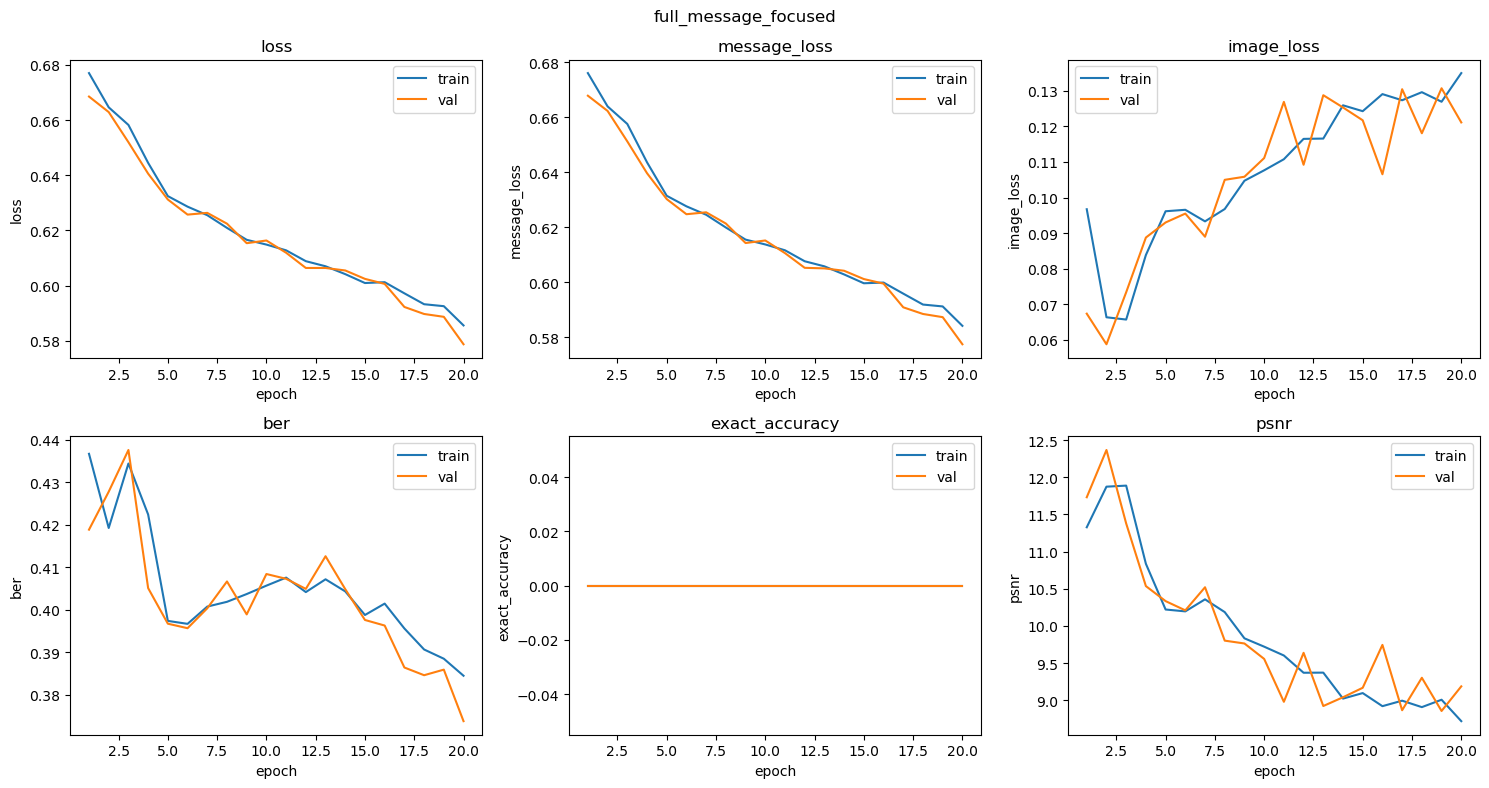

In [ ]:
full_experiment_configs = [
    {
        "name": "full_balanced",
        "learning_rate": 1e-3,
        "image_loss_weight": 0.1,
    },
    {
        "name": "full_balanced_low_lr",
        "learning_rate": 3e-4,
        "image_loss_weight": 0.1,
    },
    {
        "name": "full_message_focused",
        "learning_rate": 1e-3,
        "image_loss_weight": 0.01,
    },
]

full_experiment_results = {}

for experiment in full_experiment_configs:
    experiment_name = experiment["name"]
    config = TrainConfig(
        experiment_name=experiment_name,
        epochs=20,
        batch_size=32,
        message_length=32,
        learning_rate=experiment["learning_rate"],
        image_loss_weight=experiment["image_loss_weight"],
        device="cuda",
        checkpoint_dir=f"../results/{experiment_name}/checkpoints",
        log_path=f"../results/{experiment_name}/experiments.csv",
    )

    encoder, decoder, history = run_training(data_dir=DATA_DIR, splits_file=SPLITS_FILE, config=config, num_workers=4)

    full_experiment_results[experiment_name] = analyze_run(config.log_path, name=experiment_name)